<a href="https://colab.research.google.com/github/Taqip/PB-AMALI_THAQIF/blob/PB_AMALI/PB_AMALI_THAQIF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DKB3263 – Artificial Neural Network (ANN) MNIST

Notebook Google Colab ini disusun mengikut tugasan PB Amali DKB3263.

**Tugasan utama:**
- Membina ANN menggunakan PyTorch untuk klasifikasi MNIST digit 0–9.
- Menggunakan input layer, 1 hidden layer dan output layer.
- Menggunakan fungsi aktivasi ReLU.
- Menggunakan CrossEntropyLoss.
- Menggunakan optimizer Adam.
- Menjalankan training dan testing accuracy.
- Membuat hyperparameter tuning pada learning rate.
- Membandingkan keputusan sebelum dan selepas tuning.
- Memplot graf loss vs epoch.


## 1. Import dan Setup Library

Bahagian ini mengimport library yang diperlukan seperti PyTorch, torchvision dan matplotlib.


In [39]:
# Import library utama PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Import dataset MNIST dan DataLoader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Import matplotlib untuk menghasilkan graf
import matplotlib.pyplot as plt

print("Library berjaya diimport.")


Library berjaya diimport.


## 2. Load dan Preprocess Dataset MNIST

Dataset MNIST mengandungi imej digit tulisan tangan dari 0 hingga 9.

Preprocessing yang digunakan ialah `ToTensor()` untuk menukar imej kepada tensor PyTorch.


In [40]:
# Menukar imej MNIST kepada tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

# Dataset latihan
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Dataset ujian
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Tetapan batch size
batch_size = 64

# DataLoader untuk training
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# DataLoader untuk testing
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Jumlah data latihan:", len(train_dataset))
print("Jumlah data ujian:", len(test_dataset))


Jumlah data latihan: 60000
Jumlah data ujian: 10000


## 3. Membina Model Artificial Neural Network (ANN)

Struktur ANN:
- Input layer: 784 input (28 × 28 piksel)
- Hidden layer: 128 neuron
- Activation function: ReLU
- Output layer: 10 neuron untuk kelas digit 0–9


In [41]:
# Membina struktur ANN
class ANN(nn.Module):

    def __init__(self):
        super(ANN, self).__init__()

        # Input layer ke hidden layer
        self.hidden = nn.Linear(28 * 28, 128)

        # Fungsi aktivasi
        self.relu = nn.ReLU()

        # Hidden layer ke output layer
        self.output = nn.Linear(128, 10)

    def forward(self, x):

        # Tukar imej 28x28 kepada 784 input
        x = x.view(x.size(0), 28 * 28)

        # Forward pass
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)

        return x

print("Struktur ANN berjaya dibina.")


Struktur ANN berjaya dibina.


## 4. Sebelum Hyperparameter Tuning – Definisi Model, Loss Function dan Optimizer

Untuk eksperimen pertama:
- Learning rate = **0.01**
- Loss function = **CrossEntropyLoss**
- Optimizer = **Adam**


In [42]:
# Cipta model untuk eksperimen sebelum tuning
model_before = ANN()

# Loss function
criterion_before = nn.CrossEntropyLoss()

# Learning rate sebelum tuning
learning_rate_before = 0.01

# Optimizer
optimizer_before = optim.Adam(
    model_before.parameters(),
    lr=learning_rate_before
)

print("Learning rate sebelum tuning:", learning_rate_before)


Learning rate sebelum tuning: 0.01


## 5. Training Model Sebelum Hyperparameter Tuning

Training loop ini mengandungi:
- Forward pass
- Pengiraan loss
- Backward pass
- Update weight menggunakan optimizer


In [43]:
# Bilangan epoch
epochs = 5

# Simpan nilai loss untuk graf
loss_before = []

for epoch in range(epochs):

    model_before.train()

    total_loss = 0

    for images, labels in train_loader:

        # Reset gradient
        optimizer_before.zero_grad()

        # Forward pass
        outputs = model_before(images)

        # Kira loss
        loss = criterion_before(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weight
        optimizer_before.step()

        total_loss += loss.item()

    # Purata loss untuk setiap epoch
    average_loss = total_loss / len(train_loader)

    loss_before.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {average_loss:.4f}"
    )


Epoch 1/5 | Loss: 0.2214
Epoch 2/5 | Loss: 0.1307
Epoch 3/5 | Loss: 0.1101
Epoch 4/5 | Loss: 0.1010
Epoch 5/5 | Loss: 0.0986


## 6. Validation / Testing Accuracy Sebelum Hyperparameter Tuning

Bahagian ini menguji ketepatan model menggunakan dataset ujian MNIST.


In [44]:
# Tukar model kepada evaluation mode
model_before.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        # Dapatkan output model
        outputs = model_before(images)

        # Pilih kelas dengan nilai tertinggi
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

# Kira accuracy
accuracy_before = 100 * correct / total

print(
    f"Testing Accuracy Sebelum Tuning: "
    f"{accuracy_before:.2f}%"
)


Testing Accuracy Sebelum Tuning: 96.69%


## 7. Hyperparameter Tuning – Tukar Learning Rate

Hyperparameter yang diubah ialah **learning rate**.

- Sebelum tuning: `0.01`
- Selepas tuning: `0.001`



In [45]:
# Cipta model baru untuk eksperimen selepas tuning
model_after = ANN()

# Loss function
criterion_after = nn.CrossEntropyLoss()

# Learning rate selepas tuning
learning_rate_after = 0.001

# Optimizer
optimizer_after = optim.Adam(
    model_after.parameters(),
    lr=learning_rate_after
)

print("Learning rate selepas tuning:", learning_rate_after)


Learning rate selepas tuning: 0.001


## 8. Training Model Selepas Hyperparameter Tuning

Model dilatih semula menggunakan learning rate yang telah ditukar kepada `0.001`.


In [46]:
# Simpan nilai loss selepas tuning
loss_after = []

for epoch in range(epochs):

    model_after.train()

    total_loss = 0

    for images, labels in train_loader:

        # Reset gradient
        optimizer_after.zero_grad()

        # Forward pass
        outputs = model_after(images)

        # Kira loss
        loss = criterion_after(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weight
        optimizer_after.step()

        total_loss += loss.item()

    # Purata loss untuk setiap epoch
    average_loss = total_loss / len(train_loader)

    loss_after.append(average_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {average_loss:.4f}"
    )


Epoch 1/5 | Loss: 0.3544
Epoch 2/5 | Loss: 0.1670
Epoch 3/5 | Loss: 0.1156
Epoch 4/5 | Loss: 0.0857
Epoch 5/5 | Loss: 0.0677


## 9. Validation / Testing Accuracy Selepas Hyperparameter Tuning

Bahagian ini menguji accuracy model selepas learning rate diubah.


In [47]:
# Tukar model kepada evaluation mode
model_after.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        # Dapatkan output model
        outputs = model_after(images)

        # Pilih kelas dengan nilai tertinggi
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

# Kira accuracy
accuracy_after = 100 * correct / total

print(
    f"Testing Accuracy Selepas Tuning: "
    f"{accuracy_after:.2f}%"
)


Testing Accuracy Selepas Tuning: 97.48%


## 10. Plot Graf Loss vs Epoch

Graf ini membandingkan nilai loss sebelum dan selepas hyperparameter tuning.


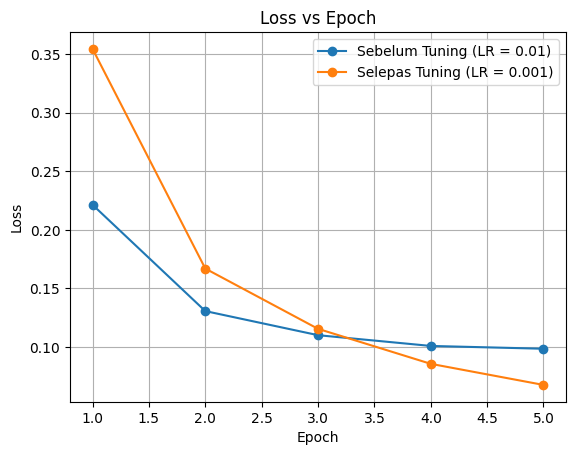

In [48]:
# Nombor epoch untuk paksi X
epoch_numbers = range(1, epochs + 1)

# Plot loss sebelum tuning
plt.plot(
    epoch_numbers,
    loss_before,
    marker="o",
    label="Sebelum Tuning (LR = 0.01)"
)

# Plot loss selepas tuning
plt.plot(
    epoch_numbers,
    loss_after,
    marker="o",
    label="Selepas Tuning (LR = 0.001)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


## 11. Perbandingan Hasil Sebelum dan Selepas Hyperparameter Tuning

Bahagian ini memaparkan perbandingan accuracy bagi kedua-dua learning rate.


In [49]:
print("===== PERBANDINGAN HASIL =====")

print(
    f"Sebelum tuning | "
    f"Learning Rate = {learning_rate_before} | "
    f"Accuracy = {accuracy_before:.2f}%"
)

print(
    f"Selepas tuning | "
    f"Learning Rate = {learning_rate_after} | "
    f"Accuracy = {accuracy_after:.2f}%"
)

difference = accuracy_after - accuracy_before

if difference > 0:
    print(
        f"Accuracy meningkat sebanyak "
        f"{difference:.2f}% selepas tuning."
    )
elif difference < 0:
    print(
        f"Accuracy menurun sebanyak "
        f"{abs(difference):.2f}% selepas tuning."
    )
else:
    print("Tiada perubahan pada accuracy.")


===== PERBANDINGAN HASIL =====
Sebelum tuning | Learning Rate = 0.01 | Accuracy = 96.69%
Selepas tuning | Learning Rate = 0.001 | Accuracy = 97.48%
Accuracy meningkat sebanyak 0.79% selepas tuning.


## 12. Semakan Benchmark Accuracy

Kriteria tugasan menetapkan benchmark accuracy testing sekurang-kurangnya **80%**.


In [50]:
# Semak sama ada model mencapai benchmark 80%
if accuracy_after >= 80:
    print(
        f"Model mencapai benchmark dengan accuracy "
        f"{accuracy_after:.2f}%."
    )
else:
    print(
        f"Accuracy semasa ialah {accuracy_after:.2f}%. "
        "Model belum mencapai benchmark 80%."
    )


Model mencapai benchmark dengan accuracy 97.48%.
